# Preprocesamiento y PCA — Titanic
Limpieza, codificación, escalado, análisis de componentes principales y exportación del dataset procesado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

sns.set_theme(style='whitegrid')

carpeta_imagenes = 'images'
carpeta_datos = 'data'
os.makedirs(carpeta_imagenes, exist_ok=True)

ruta_entrada = 'data/titanic.csv'
ruta_salida = 'data/titanic_preprocesado.csv'

datos = pd.read_csv(ruta_entrada)
print('Tamaño original:', datos.shape)


Tamaño original: (891, 12)


## 1. Imputación
- **Age:** mediana (robusta al sesgo). Se usa la mediana global por simplicidad y reproducibilidad; alternativa válida: mediana por grupo Pclass+Sex.
- **Embarked:** moda (solo 2 faltantes, valor dominante S).
- **Fare:** mediana preventiva (en este archivo no hay faltantes, pero se deja el paso para robustez).
- **Cabin:** 77 % faltante → no imputable; se crea el indicador binario **HasCabin** y se elimina la columna original.

In [2]:
print('Faltantes antes:')
print(datos.isnull().sum())

mediana_edad = datos['Age'].median()
datos['Age'] = datos['Age'].fillna(mediana_edad)

moda_embarque = datos['Embarked'].mode()[0]
datos['Embarked'] = datos['Embarked'].fillna(moda_embarque)

mediana_tarifa = datos['Fare'].median()
datos['Fare'] = datos['Fare'].fillna(mediana_tarifa)

datos['HasCabin'] = datos['Cabin'].notnull().astype(int)

print('\nFaltantes despues:')
print(datos.isnull().sum())

print('\nDistribucion de HasCabin:')
print(datos['HasCabin'].value_counts())

Faltantes antes:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Faltantes despues:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
HasCabin         0
dtype: int64

Distribucion de HasCabin:
HasCabin
0    687
1    204
Name: count, dtype: int64


## 2. Eliminación de columnas
Se eliminan **Cabin** (reemplazada por HasCabin), **Ticket** (alta cardinalidad y formato heterogéneo), **Name** (identificador de texto libre) y **PassengerId** (identificador sin señal predictiva). Ninguna aporta señal tabular directa al modelo.

In [3]:
columnas_a_borrar = ['Cabin', 'Ticket', 'Name', 'PassengerId']
datos = datos.drop(columns=columnas_a_borrar)

print('Tamaño despues de borrar:', datos.shape)
print('Columnas que quedaron:', list(datos.columns))

Tamaño despues de borrar: (891, 9)
Columnas que quedaron: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin']


## 3. Codificación (encoding)
- **Sex y Embarked:** one-hot (drop_first=True para evitar multicolinealidad).
- **Pclass:** se trata como ordinal numérica (1 < 2 < 3 tiene orden socioeconómico real) y además se conserva su valor numérico para el escalado. Se documenta la alternativa one-hot si el modelo no admite ordinalidad.

In [4]:
datos = pd.get_dummies(datos, columns=['Sex', 'Embarked'], drop_first=True)

print('Columnas con dummies:')
print(list(datos.columns))
datos.head(3)

Columnas con dummies:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True


## 4. Escalado
StandardScaler (media 0, desviación 1) sobre las numéricas Age, Fare, SibSp y Parch. Necesario para PCA y modelos basados en distancia. Survived y las dummies binarias no se escalan.

In [5]:
columnas_escalar = ['Age', 'Fare', 'SibSp', 'Parch']

escalador = StandardScaler()
datos[columnas_escalar] = escalador.fit_transform(datos[columnas_escalar])

print('Estadisticas de columnas escaladas:')
print(datos[columnas_escalar].describe().T.round(3))

Estadisticas de columnas escaladas:
       count  mean    std    min    25%    50%    75%    max
Age    891.0   0.0  1.001 -2.224 -0.566 -0.105  0.433  3.892
Fare   891.0   0.0  1.001 -0.648 -0.489 -0.357 -0.024  9.667
SibSp  891.0   0.0  1.001 -0.475 -0.475 -0.475  0.433  6.784
Parch  891.0   0.0  1.001 -0.474 -0.474 -0.474 -0.474  6.974


## 5. PCA
Se ajusta PCA con 2 componentes para visualización y se reporta la varianza explicada (tabla + gráfico de codo). Scatter PC1 vs PC2 coloreado por Survived y tabla de loadings para interpretar cada componente.

Varianza explicada: [0.3056 0.29  ]
Varianza acumulada: [0.3056 0.5956]
  Componente  Varianza_Explicada  Varianza_Acumulada
0        PC1            0.305574            0.305574
1        PC2            0.290044            0.595618


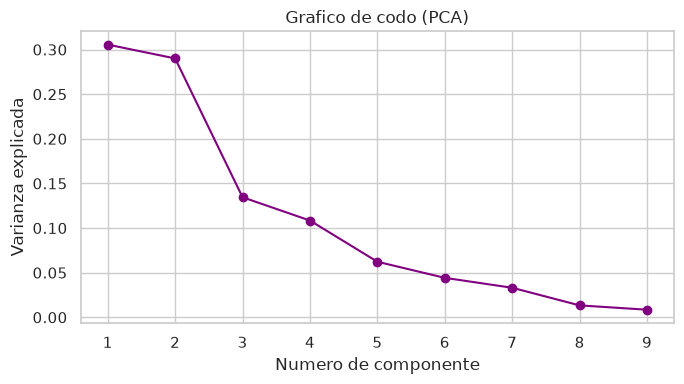

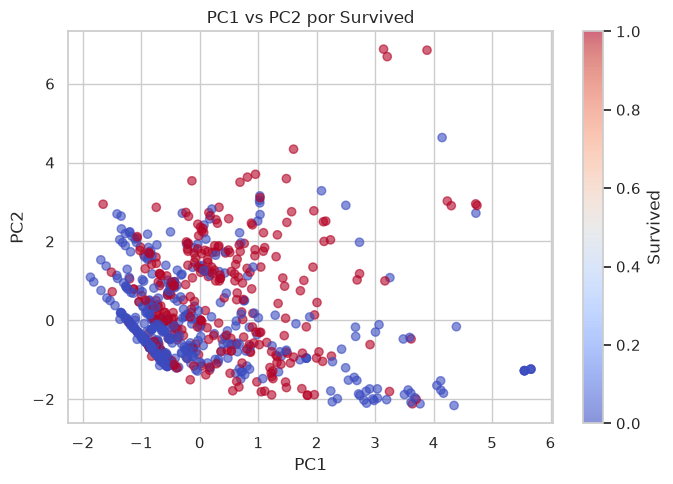

Pesos de cada variable (loadings):
              PC1    PC2
Age        -0.294  0.508
Sex_male   -0.110 -0.040
Pclass     -0.066 -0.564
Embarked_Q -0.020 -0.034
Embarked_S  0.003 -0.051
HasCabin    0.047  0.229
Fare        0.389  0.581
SibSp       0.602 -0.161
Parch       0.617 -0.053


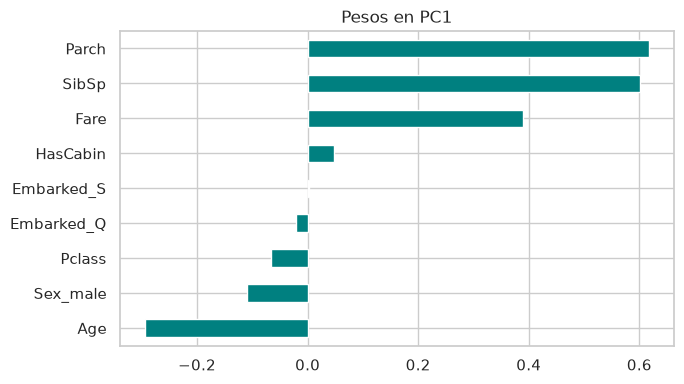

In [6]:
columnas_x = [col for col in datos.columns if col != 'Survived']
matriz_x = datos[columnas_x].values

modelo_pca = PCA(n_components=2)
componentes = modelo_pca.fit_transform(matriz_x)

varianza_explicada = modelo_pca.explained_variance_ratio_
varianza_acumulada = varianza_explicada.cumsum()

print('Varianza explicada:', np.round(varianza_explicada, 4))
print('Varianza acumulada:', np.round(varianza_acumulada, 4))

tabla_varianza = pd.DataFrame({
    'Componente': ['PC1', 'PC2'],
    'Varianza_Explicada': varianza_explicada,
    'Varianza_Acumulada': varianza_acumulada
})
print(tabla_varianza)

pca_completo = PCA().fit(matriz_x)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(pca_completo.explained_variance_ratio_) + 1),
         pca_completo.explained_variance_ratio_, marker='o', color='purple')
plt.xlabel('Numero de componente')
plt.ylabel('Varianza explicada')
plt.title('Grafico de codo (PCA)')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'pca_codo.png'))
plt.show()

plt.figure(figsize=(7, 5))
grafico_dispersion = plt.scatter(componentes[:, 0], componentes[:, 1], c=datos['Survived'].values,
                                 alpha=0.6, cmap='coolwarm')
plt.colorbar(grafico_dispersion, label='Survived')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 por Survived')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'pca_scatter.png'))
plt.show()

tabla_pesos = pd.DataFrame(modelo_pca.components_.T, index=columnas_x, columns=['PC1', 'PC2']).sort_values('PC1')
print('Pesos de cada variable (loadings):')
print(tabla_pesos.round(3))

plt.figure(figsize=(7, 4))
tabla_pesos['PC1'].plot(kind='barh', color='teal')
plt.title('Pesos en PC1')
plt.tight_layout()
plt.savefig(os.path.join(carpeta_imagenes, 'pca_loadings.png'))
plt.show()

## 6. Exportación
Se guarda el dataset preprocesado en `data/titanic_preprocesado.csv` y se verifica shape y primeras filas.

In [7]:
datos.to_csv(ruta_salida, index=False)
print('Guardado correctamente en:', ruta_salida)
print('Tamaño final:', datos.shape)
datos.head()

Guardado correctamente en: data/titanic_preprocesado.csv
Tamaño final: (891, 10)


,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.565736,0.432793,-0.473674,-0.502445,0,True,False,True
1,1,1,0.663861,0.432793,-0.473674,0.786845,1,False,False,False
2,1,3,-0.258337,-0.474545,-0.473674,-0.488854,0,False,False,True
3,1,1,0.433312,0.432793,-0.473674,0.420730,1,False,False,True
4,0,3,0.433312,-0.474545,-0.473674,-0.486337,0,True,False,True
